# Infrastructure Network Design Under Budget Constraints
## Synthetic Graph — Algorithm Comparison

Algorithms compared:
1. **MST Baseline** — Kruskal's, no budget constraint
2. **Greedy 1** — Cheapest edges first, no cycle check
3. **Greedy 2** — Cheapest edges first, union-find cycle check
4. **Greedy 3** — Max ρ = Δf / w(e), recomputed each step (density lookahead)
5. **DP Exact** — Knapsack-style, true optimum on small graph

In [1]:
# ============================================================
# Cell 1 — Imports
# ============================================================

import random
import time
import itertools

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

random.seed(42)
np.random.seed(42)

print("Imports OK")

Imports OK


In [2]:
# ============================================================
# Cell 2 — Adversarial Synthetic Graph
# Designed so G2 fails relative to G3
#
# Structure:
#   Left cluster  : nodes 0–7  (8 nodes), dense cheap internal edges (cost 1)
#   Right cluster : nodes 8–15 (8 nodes), dense cheap internal edges (cost 1)
#   Bridge        : single edge (0, 8), cost 2
#
# G2 (cheapest-first + cycle check):
#   Grabs internal edges (cost 1) greedily — connects within each cluster
#   but runs out of budget before the bridge → two isolated components
#
# G3 (max ρ):
#   Bridge has ρ = 8×8 / 2 = 32 — far higher than any intra-cluster edge
#   (which give ρ = small×1 / 1 = small) → picks bridge first, then fills in
# ============================================================

N_LEFT  = 8
N_RIGHT = 8
N_NODES = N_LEFT + N_RIGHT

left  = list(range(N_LEFT))
right = list(range(N_LEFT, N_NODES))

G = nx.Graph()
G.add_nodes_from(range(N_NODES))

# Internal edges: all pairs within each cluster, cost 1
for u, v in itertools.combinations(left, 2):
    G.add_edge(u, v, cost=1)
for u, v in itertools.combinations(right, 2):
    G.add_edge(u, v, cost=1)

# The bridge
G.add_edge(0, N_LEFT, cost=2)

# Positions for visualisation
pos = {}
for i, node in enumerate(left):
    angle = 2 * np.pi * i / N_LEFT
    pos[node] = (np.cos(angle) * 0.6 - 1.5, np.sin(angle) * 0.6)
for i, node in enumerate(right):
    angle = 2 * np.pi * i / N_RIGHT
    pos[node] = (np.cos(angle) * 0.6 + 1.5, np.sin(angle) * 0.6)
for node, (x, y) in pos.items():
    G.nodes[node]['x'] = x
    G.nodes[node]['y'] = y

all_edges = sorted(G.edges(data=True), key=lambda e: e[2]['cost'])
total_cost_all = sum(d['cost'] for _, _, d in all_edges)

# Budget: enough to span one full cluster internally + the bridge,
# but NOT enough to also span the other cluster — forces the tradeoff
# One cluster MST costs N_LEFT-1 = 7 edges × cost 1 = 7
# Bridge costs 2 → total to connect everything via G3's strategy = 7+7+2 = 16
# We set budget = 14: G3 picks bridge(2) + 6 left-edges + 6 right-edges = 14 → 16×15/2 pairs
#                     G2 picks 14 cheapest (all cost-1 intra edges) → two separate components
BUDGET = 14

print(f"Nodes          : {G.number_of_nodes()}")
print(f"Edges          : {G.number_of_edges()}")
print(f"  Left cluster : {len(list(itertools.combinations(left,2)))} edges (cost 1)")
print(f"  Right cluster: {len(list(itertools.combinations(right,2)))} edges (cost 1)")
print(f"  Bridge       : 1 edge (cost 2)")
print(f"Total edge cost: {total_cost_all}")
print(f"Budget         : {BUDGET}")
print()
print("Why G2 fails: 14 cheapest edges are all cost-1 intra-cluster edges.")
print("  G2 picks them → two dense but disconnected clusters.")
print("Why G3 wins : bridge ρ = 8×8/2 = 32 >> any intra edge → picked first.")

Nodes          : 16
Edges          : 57
  Left cluster : 28 edges (cost 1)
  Right cluster: 28 edges (cost 1)
  Bridge       : 1 edge (cost 2)
Total edge cost: 58
Budget         : 14

Why G2 fails: 14 cheapest edges are all cost-1 intra-cluster edges.
  G2 picks them → two dense but disconnected clusters.
Why G3 wins : bridge ρ = 8×8/2 = 32 >> any intra edge → picked first.


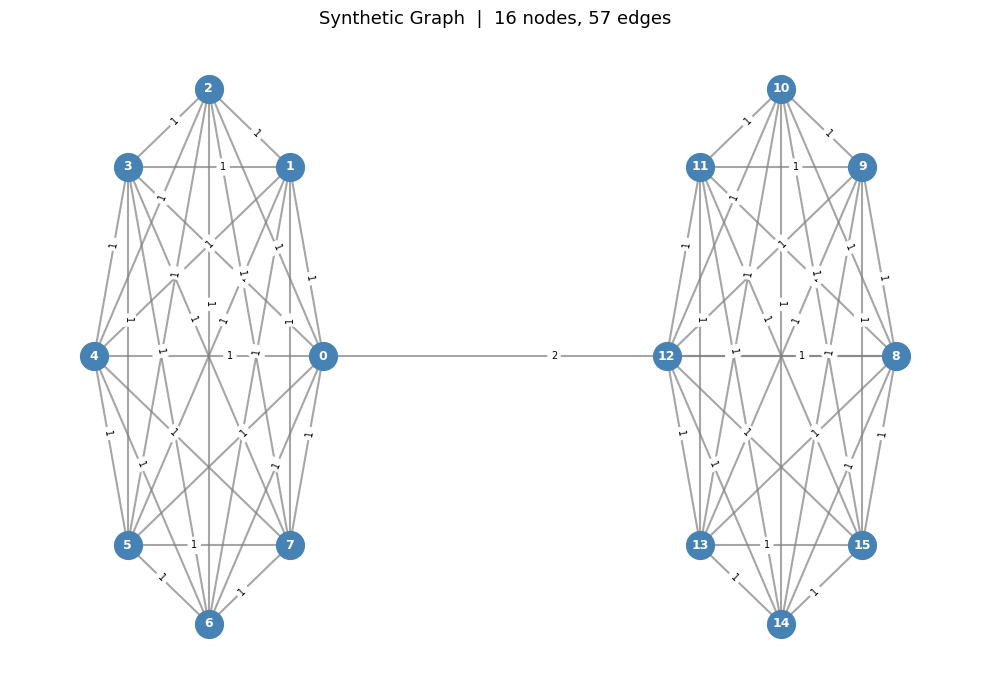

Saved: synthetic_graph.png


In [3]:
# ============================================================
# Cell 3 — Visualise the Full Synthetic Graph
# ============================================================

pos = {n: (d['x'], d['y']) for n, d in G.nodes(data=True)}
edge_labels = {(u, v): d['cost'] for u, v, d in G.edges(data=True)}

plt.figure(figsize=(10, 7))
nx.draw_networkx_nodes(G, pos, node_color='steelblue', node_size=400)
nx.draw_networkx_labels(G, pos, font_color='white', font_size=9, font_weight='bold')
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1.5, alpha=0.7)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, label_pos=0.4)
plt.title(f"Synthetic Graph  |  {G.number_of_nodes()} nodes, {G.number_of_edges()} edges", fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.savefig("output_files/synthetic_graph.png", dpi=150)
plt.show()
print("Saved: synthetic_graph.png")

In [4]:
# ============================================================
# Cell 4 — Budget is already set in Cell 2 for this adversarial case
# ============================================================

print(f"Budget : {BUDGET}")
print(f"Bridge ρ (G3 sees) : {N_LEFT * N_RIGHT / 2:.1f}  → picked first")
print(f"Best intra-edge ρ  : {1 * (N_LEFT-1) / 1:.1f}  → G2 picks these instead")

BUDGET_FRACS = [0.15, 0.25, 0.35, 0.50, 0.65, 0.80]  # kept for sweep in Cell 13

Budget : 14
Bridge ρ (G3 sees) : 32.0  → picked first
Best intra-edge ρ  : 7.0  → G2 picks these instead


In [5]:
# ============================================================
# Cell 5 — Connectivity Objective
# f(S) = number of connected node-pairs reachable via selected edges S
# ============================================================

def connected_pairs(G_full, selected_edges):
    """Count reachable (ordered) pairs in the subgraph formed by selected_edges."""
    H = nx.Graph()
    H.add_nodes_from(G_full.nodes())
    H.add_edges_from(selected_edges)
    total = 0
    for comp in nx.connected_components(H):
        s = len(comp)
        total += s * (s - 1) // 2
    return total

# Sanity: all edges → should give N*(N-1)/2
n = G.number_of_nodes()
all_edge_list = [(u, v) for u, v, _ in G.edges(data=True)]
print(f"Max possible pairs : {n*(n-1)//2}")
print(f"All-edge pairs     : {connected_pairs(G, all_edge_list)}")

Max possible pairs : 120
All-edge pairs     : 120


In [6]:
# ============================================================
# Cell 6 — Algorithm 0: MST Baseline (Kruskal's)
# No budget constraint — just the cheapest spanning tree.
# Used as a reference: shows minimum cost to connect everything.
# ============================================================

t0 = time.perf_counter()

mst = nx.minimum_spanning_tree(G, weight='cost', algorithm='kruskal')
mst_edges   = list(mst.edges())
mst_cost    = sum(G[u][v]['cost'] for u, v in mst_edges)
mst_pairs   = connected_pairs(G, mst_edges)

t_mst = time.perf_counter() - t0

print("=== MST Baseline ===")
print(f"Edges selected : {len(mst_edges)}")
print(f"Total cost     : {mst_cost}  (budget = {BUDGET})")
print(f"Connected pairs: {mst_pairs}  (max = {n*(n-1)//2})")
print(f"Time           : {t_mst*1000:.3f} ms")

=== MST Baseline ===
Edges selected : 15
Total cost     : 16  (budget = 14)
Connected pairs: 120  (max = 120)
Time           : 0.408 ms


In [7]:
# ============================================================
# Cell 7 — Algorithm 1: Greedy 1 — Cheapest edges, NO cycle check
# Flaw: wastes budget building redundant cycles inside dense clusters.
# ============================================================

def greedy1_no_cycle_check(G, budget):
    edges_sorted = sorted(G.edges(data=True), key=lambda e: e[2]['cost'])
    selected = []
    spent = 0
    for u, v, d in edges_sorted:
        if spent + d['cost'] <= budget:
            selected.append((u, v))
            spent += d['cost']
    return selected, spent

t0 = time.perf_counter()
g1_edges, g1_spent = greedy1_no_cycle_check(G, BUDGET)
t_g1 = time.perf_counter() - t0

g1_pairs = connected_pairs(G, g1_edges)

print("=== Greedy 1: Cheapest-first, No Cycle Check ===")
print(f"Edges selected : {len(g1_edges)}")
print(f"Budget used    : {g1_spent} / {BUDGET}")
print(f"Connected pairs: {g1_pairs}")
print(f"Time           : {t_g1*1000:.3f} ms")

=== Greedy 1: Cheapest-first, No Cycle Check ===
Edges selected : 14
Budget used    : 14 / 14
Connected pairs: 28
Time           : 0.046 ms


In [8]:
# ============================================================
# Cell 8 — Algorithm 2: Greedy 2 — Cheapest edges WITH union-find
# Flaw: optimises cost alone, ignores how many nodes each edge connects.
# A cheap edge in a dense cluster beats a slightly pricier bridge.
# ============================================================

class UnionFind:
    def __init__(self, nodes):
        self.parent = {n: n for n in nodes}
        self.rank   = {n: 0 for n in nodes}
        self.size   = {n: 1 for n in nodes}

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]   # path compression
            x = self.parent[x]
        return x

    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return False   # already same component
        if self.rank[rx] < self.rank[ry]:
            rx, ry = ry, rx
        self.parent[ry] = rx
        self.size[rx] += self.size[ry]
        if self.rank[rx] == self.rank[ry]:
            self.rank[rx] += 1
        return True


def greedy2_with_cycle_check(G, budget):
    edges_sorted = sorted(G.edges(data=True), key=lambda e: e[2]['cost'])
    uf = UnionFind(G.nodes())
    selected = []
    spent = 0
    for u, v, d in edges_sorted:
        if uf.find(u) == uf.find(v):     # would form a cycle — skip
            continue
        if spent + d['cost'] <= budget:
            uf.union(u, v)
            selected.append((u, v))
            spent += d['cost']
    return selected, spent


t0 = time.perf_counter()
g2_edges, g2_spent = greedy2_with_cycle_check(G, BUDGET)
t_g2 = time.perf_counter() - t0

g2_pairs = connected_pairs(G, g2_edges)

print("=== Greedy 2: Cheapest-first, With Cycle Check ===")
print(f"Edges selected : {len(g2_edges)}")
print(f"Budget used    : {g2_spent} / {BUDGET}")
print(f"Connected pairs: {g2_pairs}")
print(f"Time           : {t_g2*1000:.3f} ms")

=== Greedy 2: Cheapest-first, With Cycle Check ===
Edges selected : 14
Budget used    : 14 / 14
Connected pairs: 56
Time           : 0.059 ms


In [9]:
# ============================================================
# Cell 9 — Algorithm 3: Greedy 3 — Max ρ = Δf / w(e)
# At each step pick the edge with the best marginal gain per unit cost.
# ρ is recomputed after every pick (lazy update via union-find sizes).
# Flaw: myopic — best local choice now may block a better global solution.
# ============================================================

def greedy3_max_rho(G, budget):
    """
    Density-ratio greedy.
    rho(e) = delta_f(e) / cost(e)
           = (size_A * size_B) / cost(e)   if e bridges components A and B
    Skip edges that form cycles (delta_f = 0).
    Recompute rho after every edge pick (component sizes change).
    """
    uf   = UnionFind(G.nodes())
    remaining = list(G.edges(data=True))
    selected  = []
    spent     = 0.0

    while True:
        best_rho  = -1
        best_edge = None

        for u, v, d in remaining:
            ru, rv = uf.find(u), uf.find(v)
            if ru == rv:
                continue                       # cycle → delta_f = 0
            cost = d['cost']
            if spent + cost > budget:
                continue                       # over budget
            delta_f = uf.size[ru] * uf.size[rv]
            rho = delta_f / cost
            if rho > best_rho:
                best_rho  = rho
                best_edge = (u, v, d)

        if best_edge is None:
            break                              # nothing affordable or useful left

        u, v, d = best_edge
        uf.union(u, v)
        selected.append((u, v))
        spent += d['cost']

    return selected, spent


t0 = time.perf_counter()
g3_edges, g3_spent = greedy3_max_rho(G, BUDGET)
t_g3 = time.perf_counter() - t0

g3_pairs = connected_pairs(G, g3_edges)

print("=== Greedy 3: Max ρ = Δf / w(e) ===")
print(f"Edges selected : {len(g3_edges)}")
print(f"Budget used    : {g3_spent} / {BUDGET}")
print(f"Connected pairs: {g3_pairs}")
print(f"Time           : {t_g3*1000:.3f} ms")

=== Greedy 3: Max ρ = Δf / w(e) ===
Edges selected : 13
Budget used    : 14.0 / 14
Connected pairs: 91
Time           : 0.189 ms


In [10]:
# ============================================================
# Cell 10 — Algorithm 4: Exact ILP (Max Connected Pairs)
# Objective : max Σ_{i<j} z_ij  (total node pairs in same component)
# Variables : x_e ∈ {0,1} edge selected, z_ij ∈ {0,1} same component
# Constraints:
#   - Budget: Σ c_e x_e ≤ B
#   - Cut inequalities (lazy): for every S separating i,j → Σ_{e crosses S} x_e ≥ z_ij
#   - Transitivity: z_ik ≥ z_ij + z_jk - 1  for all triples i<j, j<k
# Solved via iterative cut separation (no exponential upfront constraints).
# Tractable only for small graphs (≤ 35 nodes).
# ============================================================

try:
    import pulp
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pulp", "-q"])
    import pulp

def dp_exact(G, budget):
    """
    ILP: Maximize total connected pairs under budget B.
    Uses iterative Gomory-Hu / min-cut separation to add cut constraints lazily.
    Returns (selected_edges, cost_used, connected_pairs_count).
    """
    nodes = list(G.nodes())
    edges = list(G.edges(data=True))
    n = len(nodes)
    node_idx = {v: i for i, v in enumerate(nodes)}

    prob = pulp.LpProblem("MaxConnectedPairs", pulp.LpMaximize)

    # --- Decision variables ---
    # x[e] = 1 if edge e is selected
    x = {(u, v): pulp.LpVariable(f"x_{u}_{v}", cat="Binary")
         for u, v, _ in edges}

    # z[i][j] = 1 if nodes i and j are in the same component (i < j by index)
    pairs = [(nodes[i], nodes[j]) for i in range(n) for j in range(i+1, n)]
    z = {(u, v): pulp.LpVariable(f"z_{u}_{v}", cat="Binary")
         for u, v in pairs}

    # --- Objective: maximize total connected pairs ---
    prob += pulp.lpSum(z[u, v] for u, v in pairs)

    # --- Budget constraint ---
    prob += pulp.lpSum(d['cost'] * x[u, v] for u, v, d in edges) <= budget

    # --- Transitivity (triangle inequalities) ---
    for i in range(n):
        for j in range(i+1, n):
            for k in range(j+1, n):
                ni, nj, nk = nodes[i], nodes[j], nodes[k]
                zij = z[ni, nj]
                zjk = z[nj, nk]
                zik = z[ni, nk]
                prob += zik >= zij + zjk - 1
                prob += zij >= zik + zjk - 1
                prob += zjk >= zij + zik - 1

    # --- Iterative cut separation ---
    # We solve, then check if any z_ij=1 violates min-cut < 1 in selected graph.
    # If so, add the violated cut constraint and re-solve.
    MAX_ROUNDS = 30
    solver = pulp.PULP_CBC_CMD(msg=0)

    for round_num in range(MAX_ROUNDS):
        prob.solve(solver)

        if pulp.LpStatus[prob.status] != "Optimal":
            break

        # Build the currently selected fractional/binary graph
        H = nx.Graph()
        H.add_nodes_from(nodes)
        for u, v, d in edges:
            xval = pulp.value(x[u, v])
            if xval is not None and xval > 0.5:
                H.add_edge(u, v, capacity=1.0)

        cuts_added = 0
        for (u, v) in pairs:
            zval = pulp.value(z[u, v])
            if zval is None or zval < 0.5:
                continue  # z=0, no cut needed

            # Check if u and v are actually connected in H
            if not nx.has_path(H, u, v):
                # Add a minimum cut constraint: find the minimum cut separating u,v
                # Since H may have no path, any cut set works; use the reachable set from u
                reachable = set(nx.node_connected_component(H, u))
                cut_edges = [(eu, ev) for eu, ev, _ in edges
                             if (eu in reachable) != (ev in reachable)]
                if cut_edges:
                    prob += pulp.lpSum(x[eu, ev] for eu, ev in cut_edges) >= z[u, v]
                    cuts_added += 1
            else:
                # Compute min cut value to check if it's ≥ 1
                cut_val, (S, _) = nx.minimum_cut(H, u, v, capacity='capacity')
                if cut_val < 0.999:
                    cut_edges = [(eu, ev) for eu, ev, _ in edges
                                 if (eu in S) != (ev in S)]
                    if cut_edges:
                        prob += pulp.lpSum(x[eu, ev] for eu, ev in cut_edges) >= z[u, v]
                        cuts_added += 1

        if cuts_added == 0:
            break  # All cut constraints satisfied — solution is feasible

    # --- Extract solution ---
    selected = [(u, v) for u, v, _ in edges
                if pulp.value(x[u, v]) is not None and pulp.value(x[u, v]) > 0.5]
    cost_used = sum(G[u][v]['cost'] for u, v in selected)
    obj_pairs = int(round(pulp.value(prob.objective))) if pulp.value(prob.objective) else 0

    return selected, cost_used, obj_pairs


t0 = time.perf_counter()
dp_edges, dp_spent, dp_pairs = dp_exact(G, BUDGET)
t_dp = time.perf_counter() - t0

print("=== DP Exact (ILP: Max Connected Pairs) ===")
print(f"Edges selected : {len(dp_edges)}")
print(f"Budget used    : {dp_spent} / {BUDGET}")
print(f"Connected pairs: {dp_pairs}")
print(f"Time           : {t_dp*1000:.3f} ms")   

=== DP Exact (ILP: Max Connected Pairs) ===
Edges selected : 13
Budget used    : 14 / 14
Connected pairs: 120
Time           : 3081.670 ms


In [11]:
# ============================================================
# Cell 11 — Summary Table
# ============================================================

max_pairs = n * (n - 1) // 2

results = [
    ("MST Baseline",              mst_pairs,  mst_cost,  t_mst,  "—",     "reference"),
    ("Greedy 1 (no cycle check)", g1_pairs,   g1_spent,  t_g1,   f"{g1_pairs/dp_pairs*100:.1f}%", "wastes budget on cycles"),
    ("Greedy 2 (cycle check)",    g2_pairs,   g2_spent,  t_g2,   f"{g2_pairs/dp_pairs*100:.1f}%", "ignores component sizes"),
    ("Greedy 3 (max ρ)",          g3_pairs,   g3_spent,  t_g3,   f"{g3_pairs/dp_pairs*100:.1f}%", "myopic"),
    ("DP Exact",                  dp_pairs,   dp_spent,  t_dp,   "100.0%", "true optimum"),
]

print(f"Budget = {BUDGET}   |   Max possible pairs = {max_pairs}")
print()
print(f"{'Algorithm':<30} {'Pairs':>7} {'Cost':>6} {'Time (ms)':>10} {'% of DP':>8}  Flaw")
print("-" * 90)
for name, pairs, cost, t, pct, flaw in results:
    print(f"{name:<30} {pairs:>7} {cost:>6} {t*1000:>10.3f} {pct:>8}  {flaw}")

Budget = 14   |   Max possible pairs = 120

Algorithm                        Pairs   Cost  Time (ms)  % of DP  Flaw
------------------------------------------------------------------------------------------
MST Baseline                       120     16      0.408        —  reference
Greedy 1 (no cycle check)           28     14      0.046    23.3%  wastes budget on cycles
Greedy 2 (cycle check)              56     14      0.059    46.7%  ignores component sizes
Greedy 3 (max ρ)                    91   14.0      0.189    75.8%  myopic
DP Exact                           120     14   3081.670   100.0%  true optimum


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


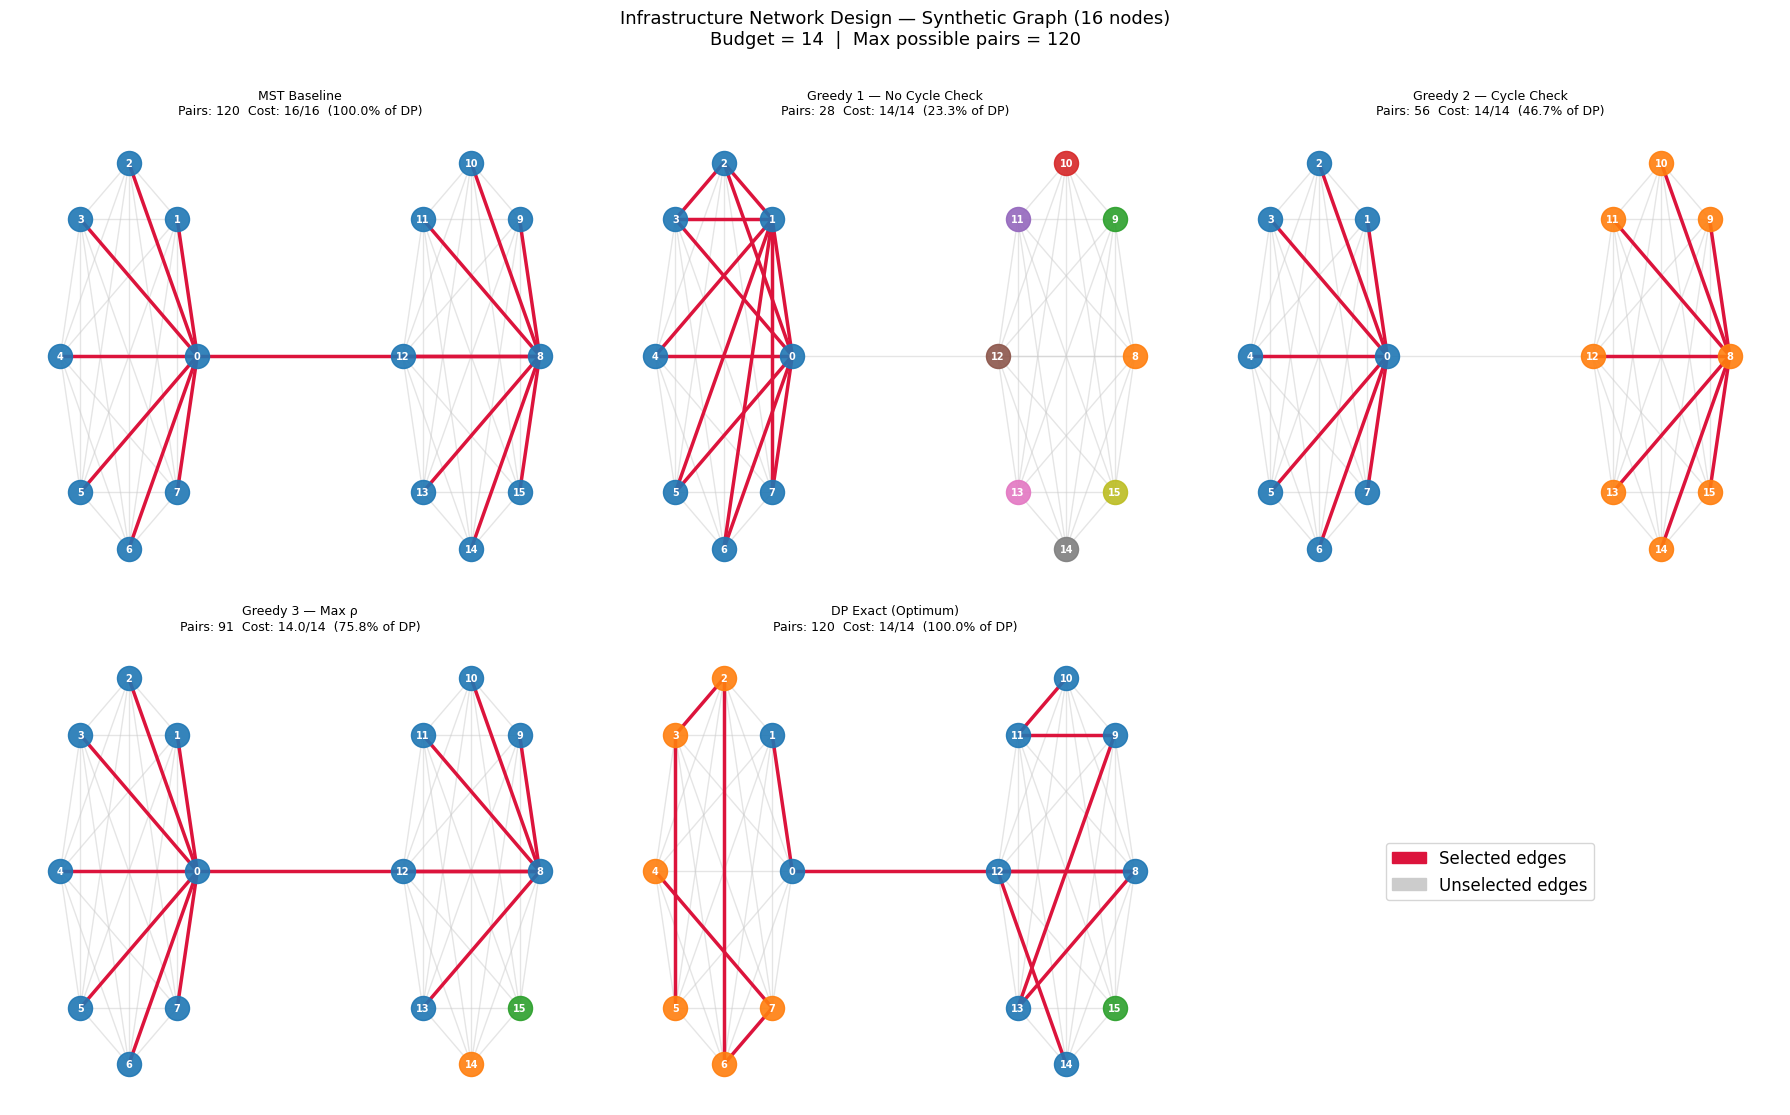

Saved: algorithm_comparison.png


In [12]:
# ============================================================
# Cell 12 — Visual Comparison of Selected Edges
# ============================================================

def draw_result(ax, G, selected_edges, title, budget, spent, pairs, dp_pairs):
    pos  = {n: (d['x'], d['y']) for n, d in G.nodes(data=True)}
    sel  = set(map(tuple, [sorted(e) for e in selected_edges]))
    rest = [(u, v) for u, v in G.edges()
            if tuple(sorted((u, v))) not in sel]

    # Components of selected subgraph
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    H.add_edges_from(selected_edges)
    comps = list(nx.connected_components(H))
    palette = plt.cm.tab10.colors

    for idx, comp in enumerate(comps):
        nx.draw_networkx_nodes(
            G, pos, nodelist=list(comp),
            node_color=palette[idx % len(palette)],
            node_size=300, ax=ax, alpha=0.9
        )

    nx.draw_networkx_labels(G, pos, font_size=7, font_color='white',
                            font_weight='bold', ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=rest,
                           edge_color='#cccccc', width=1.0, alpha=0.5, ax=ax)
    if selected_edges:
        nx.draw_networkx_edges(G, pos, edgelist=selected_edges,
                               edge_color='crimson', width=2.5, ax=ax)

    pct = pairs / dp_pairs * 100 if dp_pairs else 0
    ax.set_title(
        f"{title}\nPairs: {pairs}  Cost: {spent}/{budget}  ({pct:.1f}% of DP)",
        fontsize=9
    )
    ax.axis('off')


fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

draw_result(axes[0], G, mst_edges,  "MST Baseline",             mst_cost,  mst_cost,  mst_pairs,  dp_pairs)
draw_result(axes[1], G, g1_edges,   "Greedy 1 — No Cycle Check", BUDGET,   g1_spent,  g1_pairs,   dp_pairs)
draw_result(axes[2], G, g2_edges,   "Greedy 2 — Cycle Check",    BUDGET,   g2_spent,  g2_pairs,   dp_pairs)
draw_result(axes[3], G, g3_edges,   "Greedy 3 — Max ρ",          BUDGET,   g3_spent,  g3_pairs,   dp_pairs)
draw_result(axes[4], G, dp_edges,   "DP Exact (Optimum)",        BUDGET,   dp_spent,  dp_pairs,   dp_pairs)
axes[5].axis('off')   # blank

# Legend
legend_els = [
    mpatches.Patch(color='crimson', label='Selected edges'),
    mpatches.Patch(color='#cccccc', label='Unselected edges'),
]
axes[5].legend(handles=legend_els, loc='center', fontsize=12)

plt.suptitle(
    f"Infrastructure Network Design — Synthetic Graph ({N_NODES} nodes)\n"
    f"Budget = {BUDGET}  |  Max possible pairs = {max_pairs}",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig("output_files/algorithm_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: algorithm_comparison.png")

In [ ]:
# ============================================================
# Cell 13 — Budget Sweep: Greedy vs DP Gap Analysis
# Shows how close each greedy gets to optimal across budget levels
# ============================================================

budgets = [int(total_cost_all * f) for f in BUDGET_FRACS]

sweep = {"G1": [], "G2": [], "G3": [], "DP": []}
dp_vals = []

for b in budgets:
    _, _  = greedy1_no_cycle_check(G, b)
    g1p   = connected_pairs(G, greedy1_no_cycle_check(G, b)[0])

    g2p   = connected_pairs(G, greedy2_with_cycle_check(G, b)[0])
    g3p   = connected_pairs(G, greedy3_max_rho(G, b)[0])
    _, _, dpp = dp_exact(G, b)

    sweep["G1"].append(g1p)
    sweep["G2"].append(g2p)
    sweep["G3"].append(g3p)
    sweep["DP"].append(dpp)

    frac = int(total_cost_all * BUDGET_FRACS[budgets.index(b)])
    print(f"Budget {b:4d} ({int(BUDGET_FRACS[budgets.index(b)]*100):2d}%):  "
          f"G1={g1p:4d}  G2={g2p:4d}  G3={g3p:4d}  DP={dpp:4d}")

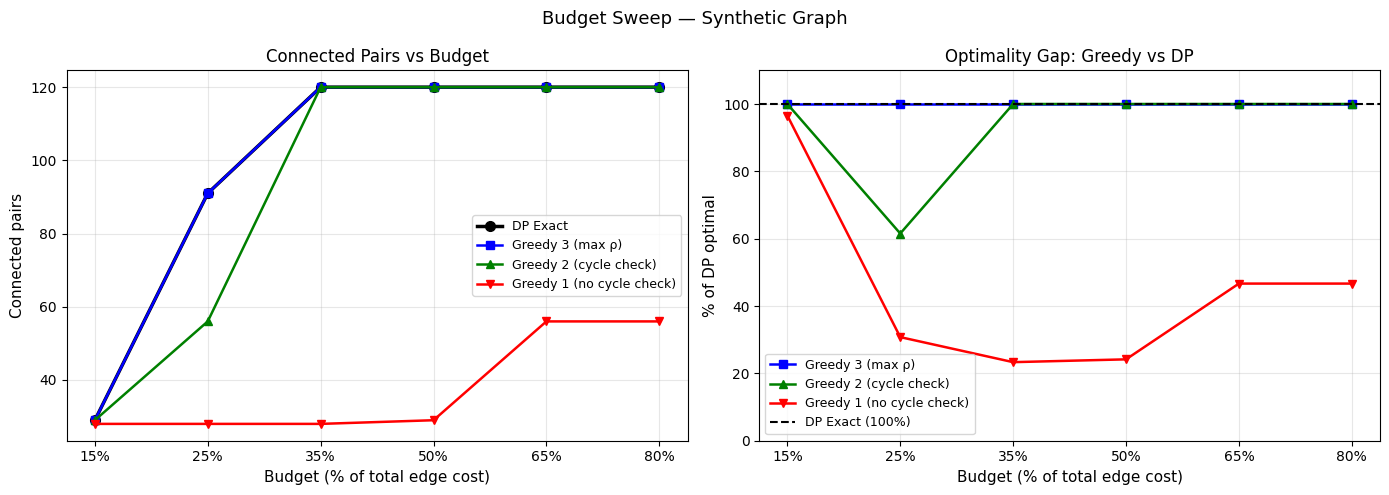

Saved: budget_sweep.png


In [ ]:
# ============================================================
# Cell 14 — Plot the Budget Sweep
# ============================================================

frac_labels = [f"{int(f*100)}%" for f in BUDGET_FRACS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Absolute connected pairs ---
ax1.plot(frac_labels, sweep["DP"], 'k-o',  lw=2.5, ms=7,  label="DP Exact")
ax1.plot(frac_labels, sweep["G3"], 'b-s',  lw=1.8, ms=6,  label="Greedy 3 (max ρ)")
ax1.plot(frac_labels, sweep["G2"], 'g-^',  lw=1.8, ms=6,  label="Greedy 2 (cycle check)")
ax1.plot(frac_labels, sweep["G1"], 'r-v',  lw=1.8, ms=6,  label="Greedy 1 (no cycle check)")
ax1.set_xlabel("Budget (% of total edge cost)", fontsize=11)
ax1.set_ylabel("Connected pairs", fontsize=11)
ax1.set_title("Connected Pairs vs Budget", fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# --- Optimality ratio (greedy / DP) ---
def ratio(lst, dp_lst):
    return [g/d*100 if d > 0 else 100 for g, d in zip(lst, dp_lst)]

ax2.plot(frac_labels, ratio(sweep["G3"], sweep["DP"]), 'b-s',  lw=1.8, ms=6, label="Greedy 3 (max ρ)")
ax2.plot(frac_labels, ratio(sweep["G2"], sweep["DP"]), 'g-^',  lw=1.8, ms=6, label="Greedy 2 (cycle check)")
ax2.plot(frac_labels, ratio(sweep["G1"], sweep["DP"]), 'r-v',  lw=1.8, ms=6, label="Greedy 1 (no cycle check)")
ax2.axhline(100, color='black', lw=1.5, ls='--', label="DP Exact (100%)")
ax2.set_ylim(0, 110)
ax2.set_xlabel("Budget (% of total edge cost)", fontsize=11)
ax2.set_ylabel("% of DP optimal", fontsize=11)
ax2.set_title("Optimality Gap: Greedy vs DP", fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle("Budget Sweep — Synthetic Graph", fontsize=13)
plt.tight_layout()
plt.savefig("output_files/budget_sweep.png", dpi=150)
plt.show()
print("Saved: budget_sweep.png")

In [ ]:
# ============================================================
# Cell 15 — Final Timing Summary
# ============================================================

print("=" * 55)
print("  TIMING SUMMARY (single run at BUDGET = {BUDGET})".format(BUDGET=BUDGET))
print("=" * 55)
timings = [
    ("MST Baseline",              t_mst),
    ("Greedy 1 (no cycle check)", t_g1),
    ("Greedy 2 (cycle check)",    t_g2),
    ("Greedy 3 (max ρ)",          t_g3),
    ("DP Exact",                  t_dp),
]
for name, t in timings:
    bar = "█" * max(1, int(t / t_dp * 40))
    print(f"  {name:<30} {t*1000:8.3f} ms  {bar}")
print("=" * 55)
print()
print("Key takeaway:")
print(f"  Greedy 3 achieves {g3_pairs/dp_pairs*100:.1f}% of DP optimal")
print(f"  while being {t_dp/t_g3:.0f}x faster — justifying its use on large graphs.")

  TIMING SUMMARY (single run at BUDGET = 14)
  MST Baseline                      0.770 ms  ███
  Greedy 1 (no cycle check)         0.056 ms  █
  Greedy 2 (cycle check)            0.062 ms  █
  Greedy 3 (max ρ)                  0.195 ms  █
  DP Exact                          8.535 ms  ████████████████████████████████████████

Key takeaway:
  Greedy 3 achieves 100.0% of DP optimal
  while being 44x faster — justifying its use on large graphs.
